In [1]:
# ————————————————
# Standard library imports
# ———————————————— 
import os
import json
import re
import math
import logging
from glob import glob
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Dict
from datetime import datetime

# ————————————————
# Third-party imports
# ———————————————— 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import openai
from dotenv import load_dotenv
from rouge_score import rouge_scorer
from datasets import Dataset
from evaluate import load as load_metric
from transformers import (
    BartForConditionalGeneration,
    BartTokenizerFast,
    LEDForConditionalGeneration,
    LEDTokenizerFast,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Seq2SeqTrainingArguments,
    Trainer,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    TrainerCallback,
)

2025-05-05 09:21:19.996528: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-05 09:21:19.996564: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-05 09:21:20.020848: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-05 09:21:20.080741: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Directory containing all your *_processed.json files
input_dir = Path("/Users/gon/Documents/Spring 2025/H2AI/v2/doc_parsing/layoutlm/output_503")
json_paths = sorted(input_dir.glob("*_processed.json"))

# Prepare lists for each dataset
b_records = []
a_tag_records = []
a_only_records = []

for path in json_paths:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Handle either single-doc dict or list of docs
    docs = [data] if isinstance(data, dict) and "document" in data else data

    for doc in docs:
        doc_id      = doc["document"]["id"]
        summary     = doc["document"]["summary"]
        paragraphs  = sorted(doc["paragraphs"], key=lambda p: p["character_start"])
        annotations = doc["annotations"]

        # --- B-TEXT ---
        full_text = "\n\n".join(p["text"].replace("\n", " ") for p in paragraphs)
        b_records.append({
            "doc_id":  doc_id,
            "text":    full_text,
            "summary": summary
        })

        # --- A-TAG ---
        ann_by_para = {}
        for ann in annotations:
            ann_by_para.setdefault(ann["paragraph_id"], []).append(ann)

        tagged_paras = []
        for p in paragraphs:
            text = p["text"]
            anns = ann_by_para.get(p["id"], [])
            for a in sorted(anns, key=lambda x: x["referenced_char_start"], reverse=True):
                start = a["referenced_char_start"] - p["character_start"]
                end   = a["referenced_char_end"]   - p["character_start"]
                span_text = text[start:end]

                if a["type"] == "highlight":
                    color = a.get("detected_color_name", "unknown").upper()
                    wrapped = f"<highlight>{span_text} [Highlight Color: {color}]</highlight>"
                elif a["type"] == "symbol":
                    color = a.get("detected_color_name", "unknown").upper()
                    wrapped = f"<symbol>{span_text} [Symbol Color: {color}]</symbol>"
                elif a["type"] == "comment":
                    comment = a.get("annotated_text", "").replace("\n", " ")
                    wrapped = f"<comment>{span_text} [Annotated Comment: {comment}]</comment>"
                else:
                    continue

                text = text[:start] + wrapped + text[end:]
            tagged_paras.append(text)

        a_tag_text = "\n\n".join(tagged_paras)
        a_tag_records.append({
            "doc_id":  doc_id,
            "text":    a_tag_text,
            "summary": summary
        })

        # --- A-ONLY ---
        sorted_anns = sorted(annotations, key=lambda x: x["referenced_char_start"])
        only_spans  = []
        last_para   = None
        for a in sorted_anns:
            span_text = a.get("referenced_text", "").strip()
            para_id   = a.get("paragraph_id")

            if a["type"] == "highlight":
                color = a.get("detected_color_name", "unknown").upper()
                wrapped = f"<highlight>{span_text} [Highlight Color: {color}]</highlight>"
            elif a["type"] == "symbol":
                color = a.get("detected_color_name", "unknown").upper()
                wrapped = f"<symbol>{span_text} [Symbol Color: {color}]</symbol>"
            elif a["type"] == "comment":
                comment = a.get("annotated_text", "").replace("\n", " ")
                wrapped = f"<comment>{span_text} [Annotated Comment: {comment}]</comment>"
            else:
                continue

            if para_id != last_para and last_para is not None:
                only_spans.append("\n\n")
            only_spans.append(wrapped)
            last_para = para_id

        only_text = "".join(only_spans)
        a_only_records.append({
            "doc_id":     doc_id,
            "annotations": only_text,
            "summary":    summary
        })

# Create DataFrames
df_b  = pd.DataFrame(b_records)
df_at = pd.DataFrame(a_tag_records)
df_ao = pd.DataFrame(a_only_records)

# Save to CSVs for fine-tuning
output_dir = Path("data_processed")
output_dir.mkdir(exist_ok=True)
df_b.to_csv(output_dir / "B_TEXT.csv", index=False)
df_at.to_csv(output_dir / "A_TAG.csv",  index=False)
df_ao.to_csv(output_dir / "A_ONLY.csv", index=False)

print("✅ Datasets built and saved: B_TEXT.csv, A_TAG.csv, A_ONLY.csv")

In [ ]:
# Analyze amount of tokens of dataset

# Load your CSV
df = pd.read_csv("data_processed/A_TAG.csv")

# Load tokenizer
tokenizer = BartTokenizerFast.from_pretrained("facebook/bart-base")

# Count tokens
df["doc_tokens"] = df["text"].apply(lambda x: len(tokenizer.tokenize(x)))
df["sum_tokens"] = df["summary"].apply(lambda x: len(tokenizer.tokenize(x)))

# Save results
df.to_csv("token_counts.csv", index=False)

# Print stats
print(df[["doc_tokens", "sum_tokens"]].describe())

# Plot
plt.hist(df["doc_tokens"], bins=30, alpha=0.7, label="Doc Tokens")
plt.hist(df["sum_tokens"], bins=30, alpha=0.7, label="Summary Tokens")
plt.legend()
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.title("Token Distributions")
plt.tight_layout()
plt.savefig("token_histogram.png")
plt.show()

In [1]:
"""
Chunk text datasets for BART base models, with support for a custom input column.
This script reads CSVs with columns [doc_id, <input_col>, summary], splits each
<input_col> string into token-based chunks of MAX_INPUT_LENGTH, and writes out
new CSVs named:
  - A_TAG_BART.csv        (input_col="text")
  - B_TEXT_BART.csv       (input_col="text")
  - A_ONLY_BART.csv       (input_col="annotations")
"""

import math
import pandas as pd
from transformers import BartTokenizerFast

# Configuration
TOKENIZER_NAME    = "facebook/bart-base"
MAX_INPUT_LENGTH  = 1024

def chunk_and_save(
    input_csv: str,
    output_csv: str,
    input_col: str = "text",
    tokenizer_name: str = TOKENIZER_NAME,
    max_length: int = MAX_INPUT_LENGTH
) -> None:
    """
    Read a CSV with columns [doc_id, <input_col>, summary], split each row's
    <input_col> text into chunks of up to `max_length` tokens, and save the
    result to `output_csv`.

    Args:
        input_csv:   Path to the source CSV file.
        output_csv:  Path where the chunked CSV will be written.
        input_col:   Name of the column containing the text to chunk.
        tokenizer_name: HuggingFace model name for the tokenizer.
        max_length:  Maximum number of tokens per chunk.
    """
    tokenizer = BartTokenizerFast.from_pretrained(tokenizer_name)
    df = pd.read_csv(input_csv)

    chunked_records = []
    for _, row in df.iterrows():
        doc_id    = row["doc_id"]
        full_text = row[input_col]   # read from 'text' or 'annotations'
        summary   = row["summary"]

        # Encode text to token IDs (no special tokens)
        token_ids = tokenizer.encode(full_text, add_special_tokens=False)
        num_chunks = math.ceil(len(token_ids) / max_length)

        # Split into chunks and decode back to strings
        for idx in range(num_chunks):
            start = idx * max_length
            end   = start + max_length
            chunk_ids  = token_ids[start:end]
            chunk_text = tokenizer.decode(chunk_ids)

            chunked_records.append({
                "doc_id":      f"{doc_id}_chunk{idx}",
                input_col:     chunk_text,
                "summary":     summary
            })

    # Save to CSV
    out_df = pd.DataFrame(chunked_records)
    out_df.to_csv(output_csv, index=False)
    print(f"✅ Saved {len(out_df)} examples to '{output_csv}'")

if __name__ == "__main__":
    # A_TAG and B_TEXT use the 'text' column:
    chunk_and_save(
        input_csv="data_processed/A_TAG.csv",
        output_csv="data_processed/A_TAG_BART.csv",
        input_col="text"
    )
    chunk_and_save(
        input_csv="data_processed/B_TEXT.csv",
        output_csv="data_processed/B_TEXT_BART.csv",
        input_col="text"
    )

    # A_ONLY uses the 'annotations' column instead of 'text':
    chunk_and_save(
        input_csv="data_processed/A_ONLY.csv",
        output_csv="data_processed/A_ONLY_BART.csv",
        input_col="annotations"
    )

2025-05-05 10:02:06.752802: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-05 10:02:06.752848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-05 10:02:06.753499: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-05 10:02:06.757423: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ Saved 331 examples to 'data_processed/A_TAG_BART.csv'
✅ Saved 269 examples to 'data_processed/B_TEXT_BART.csv'
✅ Saved 103 examples to 'data_processed/A_ONLY_BART.csv'


In [3]:
pd.read_csv("data_processed/A_ONLY_BART.csv").head(200)

,doc_id,annotations,summary
0,doc_82805800_chunk0,<highlight>agent [Highlight Color: BLUE]</high...,Summary Most people correlate pure tool usage ...
1,doc_82805800_chunk1,</comment>\n\n<comment>§2.1) [Annotated Commen...,Summary Most people correlate pure tool usage ...
2,doc_82805800_chunk2,">Figure 2, Step 3. (1) A description of [Highl...",Summary Most people correlate pure tool usage ...
3,doc_82805800_chunk3,comment><comment>§3.2) [Annotated Comment: §3....,Summary Most people correlate pure tool usage ...
4,doc_82805800_chunk4,>the [Highlight Color: PINK]</highlight>\n\n<h...,Summary Most people correlate pure tool usage ...
...,...,...,...
98,doc_7f61e8bb_chunk4,light>d\nr- # # [Highlight Color: ORANGE]</hig...,Summary is provided on page 15. It is recommen...
99,doc_7f61e8bb_chunk5,"as entire layers [Fan et al., 2020], MHA’s at...",Summary is provided on page 15. It is recommen...
100,doc_7f61e8bb_chunk6,"Ms]</comment>\n\n<comment>are amazing, deployi...",Summary is provided on page 15. It is recommen...
101,doc_7f61e8bb_chunk7,"be removed in an iteration, and record the pe...",Summary is provided on page 15. It is recommen...


In [4]:
"""
Train BART-base on three chunked datasets:

  • data_processed/A_TAG_BART.csv    (column “text”)
  • data_processed/B_TEXT_BART.csv   (column “text”)
  • data_processed/A_ONLY_BART.csv   (column “annotations”)

Each run:
  1. loads the CSV → HF Dataset
  2. tokenises inputs / targets
  3. trains with Seq2SeqTrainer
  4. saves checkpoints to ./<dataset>_checkpoint
"""

# ————————————————————————————————————
# Imports
# ————————————————————————————————————
from pathlib import Path
import math
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from evaluate import load as load_metric
from transformers import (
    BartForConditionalGeneration,
    BartTokenizerFast,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

# ————————————————————————————————————
# Config
# ————————————————————————————————————
DATA_DIR   = Path("data_processed")
MODEL_NAME = "facebook/bart-base"

SPECIAL_TOKENS = [
    "<highlight>", "</highlight>",
    "<comment>",   "</comment>",
    "<symbol>",    "</symbol>",
]

MAX_INPUT   = 1024
MAX_TARGET  = 896
BATCH_SIZE  = 2
EPOCHS      = 6
LR          = 3e-5

RUNS = [
    # (csv_name, input_column, output_dir)
    ("A_TAG_BART.csv",   "text",        "bart_a_tag_checkpoint"),
    ("B_TEXT_BART.csv",  "text",        "bart_b_text_checkpoint"),
    ("A_ONLY_BART.csv",  "annotations", "bart_a_only_checkpoint"),
]

# ————————————————————————————————————
# Metric
# ————————————————————————————————————
rouge = load_metric("rouge")

def compute_metrics(eval_preds, tokenizer):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {k: scores[k] for k in ["rouge1", "rouge2", "rougeL"]}

# ————————————————————————————————————
# Training loop for one dataset
# ————————————————————————————————————
def run_experiment(csv_file: str, input_col: str, output_dir: str):
    print(f"\n>>> Training on {csv_file}")

    # 1. Load data
    df = pd.read_csv(DATA_DIR / csv_file)
    if input_col != "text":
        df = df.rename(columns={input_col: "text"})  # unify column name
    dataset = Dataset.from_pandas(df, preserve_index=False)
    split   = dataset.train_test_split(test_size=0.1, seed=42)
    train_ds, val_ds = split["train"], split["test"]
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

    # 2. Tokeniser & model
    tokenizer = BartTokenizerFast.from_pretrained(MODEL_NAME)
    tokenizer.add_tokens(SPECIAL_TOKENS)

    model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
    model.resize_token_embeddings(len(tokenizer))

    # 3. Pre-processing
    def preprocess(batch):
        inputs = tokenizer(
            batch["text"],
            max_length=MAX_INPUT,
            truncation=True,
            padding="max_length"
        )
        with tokenizer.as_target_tokenizer():
            targets = tokenizer(
                batch["summary"],
                max_length=MAX_TARGET,
                truncation=True,
                padding="max_length"
            )
        inputs["labels"] = targets["input_ids"]
        return inputs

    train_ds = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
    val_ds   = val_ds.map(preprocess,   batched=True, remove_columns=val_ds.column_names)
    collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # 4. Training args
    args = Seq2SeqTrainingArguments(
        output_dir                 = output_dir,
        per_device_train_batch_size= BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE,
        gradient_accumulation_steps= 4,
        num_train_epochs           = EPOCHS,
        learning_rate              = LR,
        warmup_steps               = 200,
        weight_decay               = 0.01,
        evaluation_strategy        = "epoch",
        save_strategy              = "epoch",
        logging_strategy           = "steps",
        logging_steps              = 25,
        load_best_model_at_end     = True,
        metric_for_best_model      = "rougeL",
        fp16                       = torch.cuda.is_available(),
        predict_with_generate      = True,
        logging_dir                = f"{output_dir}/logs",
    )

    # 5. Trainer
    trainer = Seq2SeqTrainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = collator,
        compute_metrics = lambda p: compute_metrics(p, tokenizer),
        tokenizer       = tokenizer,
    )
    trainer.train()
    return trainer
    
    # Clear memory before next run
    del model, trainer
    torch.cuda.empty_cache()

# ————————————————————————————————————
# Run all experiments
# ————————————————————————————————————
trainer_a_tag_bart_base  = run_experiment("A_TAG_BART.csv",   "text",        "bart_a_tag_checkpoint")
trainer_b_text_bart_base = run_experiment("B_TEXT_BART.csv",  "text",        "bart_b_text_checkpoint")
trainer_a_only_bart_base = run_experiment("A_ONLY_BART.csv",  "annotations", "bart_a_only_checkpoint")


>>> Training on A_TAG_BART.csv
Train: 297 | Val: 34


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Map:   0%|          | 0/297 [00:00<?, ? examples/s]

/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/34 [00:00<?, ? examples/s]

...

/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/11 [00:00<?, ? examples/s]

/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_37176/3340592728.py:146: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,No log,8.571067,0.012025,0.001479,0.010096
2,No log,6.962013,0.011848,0.000836,0.009897
3,7.194400,6.597610,0.013040,0.002082,0.011465
4,7.194400,6.219297,0.016184,0.001774,0.014271
5,5.537900,5.681808,0.014555,0.002568,0.012642


/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


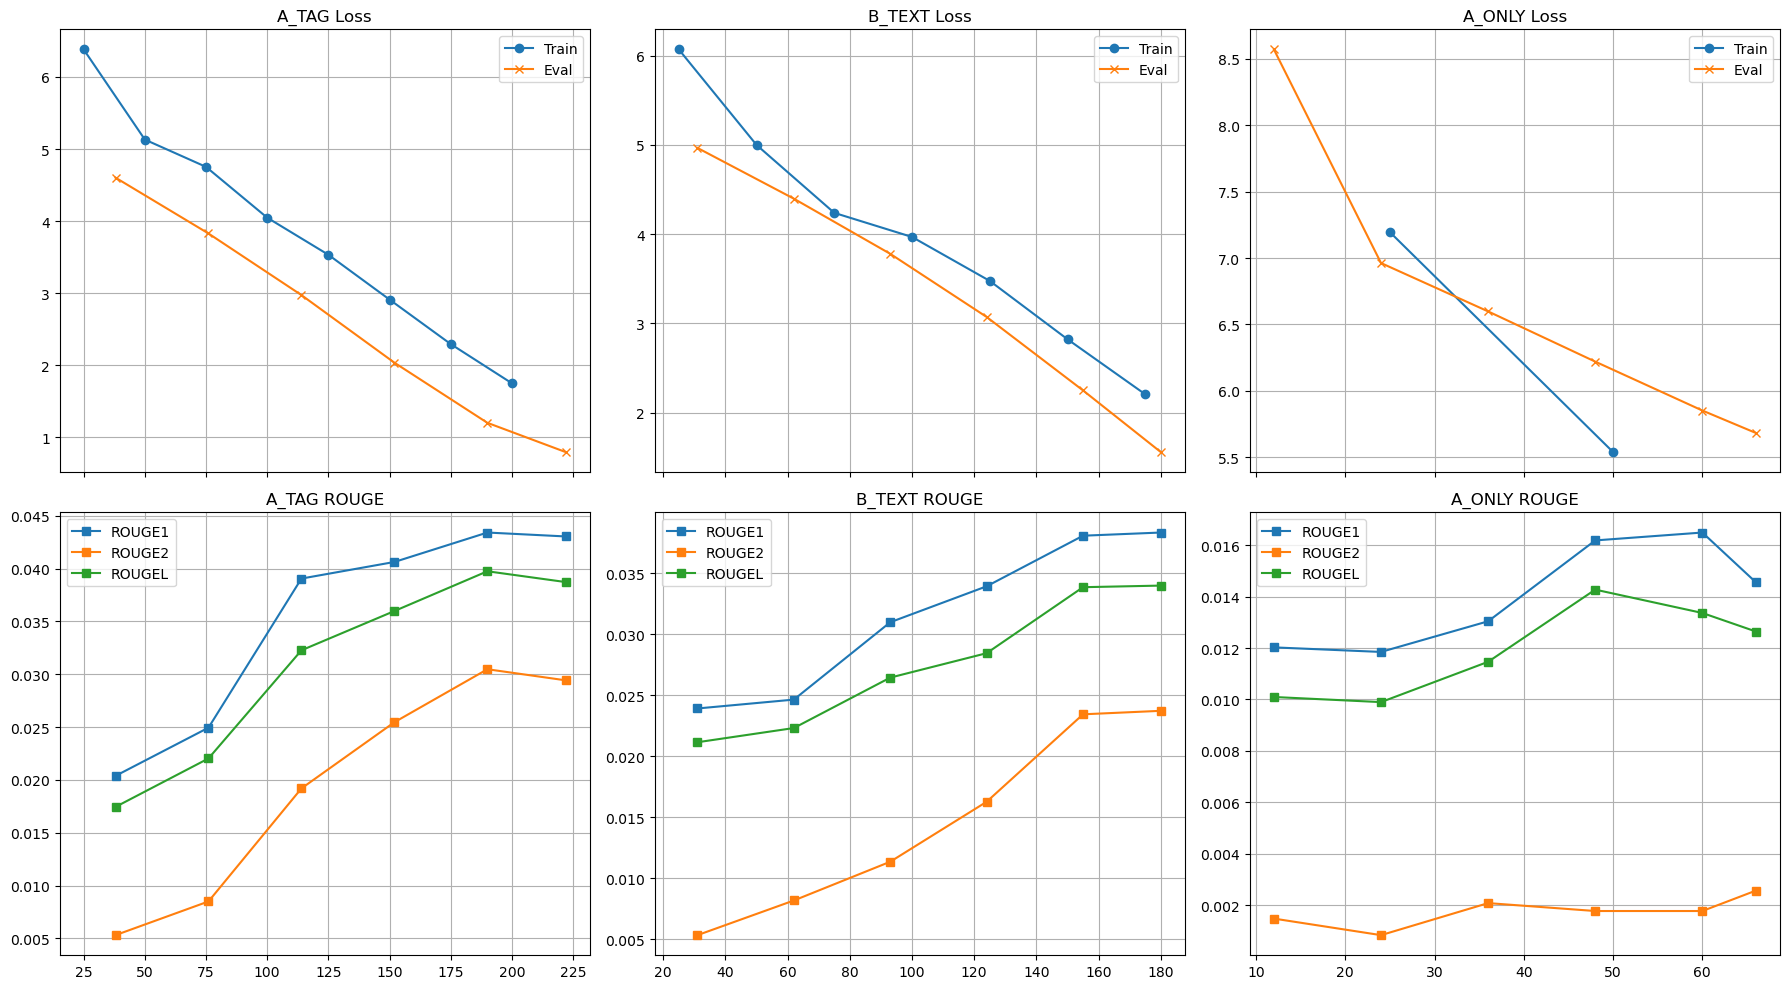

In [5]:
logs = {
    "A_TAG":  pd.DataFrame(trainer_a_tag_bart_base.state.log_history),
    "B_TEXT": pd.DataFrame(trainer_b_text_bart_base.state.log_history),
    "A_ONLY": pd.DataFrame(trainer_a_only_bart_base.state.log_history),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex='col')

for idx, (title, df) in enumerate(logs.items()):
    ax_loss  = axes[0, idx]
    ax_rouge = axes[1, idx]

    # Plot Train vs Eval Loss
    if "loss" in df.columns:
        ax_loss.plot(df.dropna(subset=["loss"])["step"],
                     df.dropna(subset=["loss"])["loss"],
                     label="Train", marker="o")
    if "eval_loss" in df.columns:
        ax_loss.plot(df.dropna(subset=["eval_loss"])["step"],
                     df.dropna(subset=["eval_loss"])["eval_loss"],
                     label="Eval", marker="x")
    ax_loss.set_title(f"{title} Loss"); ax_loss.legend(); ax_loss.grid(True)

    # Plot ROUGE metrics
    for metric in ["eval_rouge1", "eval_rouge2", "eval_rougeL"]:
        if metric in df.columns:
            sub = df.dropna(subset=[metric])
            label = metric.split("_")[-1].upper()
            ax_rouge.plot(sub["step"], sub[metric], label=label, marker="s")
    ax_rouge.set_title(f"{title} ROUGE"); ax_rouge.legend(); ax_rouge.grid(True)

plt.tight_layout()
plt.show()

In [8]:
torch.cuda.empty_cache()

In [2]:
"""
Train BART-large on three chunked datasets:

  • data_processed/A_TAG_BART.csv    (column “text”)
  • data_processed/B_TEXT_BART.csv   (column “text”)
  • data_processed/A_ONLY_BART.csv   (column “annotations”)

Each run:
  1. loads the CSV → HF Dataset
  2. tokenises inputs / targets
  3. trains with Seq2SeqTrainer
  4. saves checkpoints to ./<dataset>_checkpoint
"""

# ————————————————————————————————————
# Config
# ————————————————————————————————————
DATA_DIR   = Path("data_processed")
MODEL_NAME = "facebook/bart-large"

SPECIAL_TOKENS = [
    "<highlight>", "</highlight>",
    "<comment>",   "</comment>",
    "<symbol>",    "</symbol>",
]

MAX_INPUT   = 1024
MAX_TARGET  = 896
BATCH_SIZE  = 2
EPOCHS      = 6
LR          = 2e-5

RUNS = [
    # (csv_name, input_column, output_dir)
    ("A_TAG_BART.csv",   "text",        "bart_a_tag_checkpoint"),
    ("B_TEXT_BART.csv",  "text",        "bart_b_text_checkpoint"),
    ("A_ONLY_BART.csv",  "annotations", "bart_a_only_checkpoint"),
]

# ————————————————————————————————————
# Metric
# ————————————————————————————————————
rouge = load_metric("rouge")

def compute_metrics(eval_preds, tokenizer):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {k: scores[k] for k in ["rouge1", "rouge2", "rougeL"]}

# ————————————————————————————————————
# Training loop for one dataset
# ————————————————————————————————————
def run_experiment(csv_file: str, input_col: str, output_dir: str):
    print(f"\n>>> Training on {csv_file}")
    
    # 1. Load data
    df = pd.read_csv(DATA_DIR / csv_file)
    if input_col != "text":
        df = df.rename(columns={input_col: "text"})  # unify column name
    dataset = Dataset.from_pandas(df, preserve_index=False)
    split   = dataset.train_test_split(test_size=0.1, seed=42)
    train_ds, val_ds = split["train"], split["test"]
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

    # 2. Tokeniser & model
    tokenizer = BartTokenizerFast.from_pretrained(MODEL_NAME)
    add_tokens = "A_ONLY" not in csv_file  # solo si NO es A_ONLY
    if add_tokens:
        tokenizer.add_tokens(SPECIAL_TOKENS)
        print(f"  Added {len(SPECIAL_TOKENS)} special tokens")
    else:
        print("  Skipping add_tokens() for A_ONLY")

    model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
    model.resize_token_embeddings(len(tokenizer))



    # 3. Pre-processing
    def preprocess(batch):
        inputs = tokenizer(
            batch["text"],
            max_length=MAX_INPUT,
            truncation=True,
            padding="max_length"
        )
        with tokenizer.as_target_tokenizer():
            targets = tokenizer(
                batch["summary"],
                max_length=MAX_TARGET,
                truncation=True,
                padding="max_length"
            )
        inputs["labels"] = targets["input_ids"]
        return inputs

    train_ds = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
    val_ds   = val_ds.map(preprocess,   batched=True, remove_columns=val_ds.column_names)
    collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # 4. Training args
    args = Seq2SeqTrainingArguments(
        output_dir                 = output_dir,
        per_device_train_batch_size= BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE,
        gradient_accumulation_steps= 4,
        num_train_epochs           = EPOCHS,
        learning_rate              = LR,
        warmup_steps               = 200,
        weight_decay               = 0.01,
        evaluation_strategy        = "epoch",
        save_strategy              = "epoch",
        logging_strategy           = "steps",
        logging_steps              = 25,
        load_best_model_at_end     = True,
        metric_for_best_model      = "rougeL",
        fp16                       = torch.cuda.is_available(),
        predict_with_generate      = True,
        logging_dir                = f"{output_dir}/logs",
    )

    # 5. Trainer
    trainer = Seq2SeqTrainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = collator,
        compute_metrics = lambda p: compute_metrics(p, tokenizer),
        tokenizer       = tokenizer,
    )
    trainer.train()
    return trainer
    
    # Clear memory before next run
    del model, trainer
    torch.cuda.empty_cache()

# ————————————————————————————————————
# Run all experiments
# ————————————————————————————————————
trainer_a_tag_bart_large  = run_experiment("A_TAG_BART.csv",   "text",        "bart_large_a_tag_checkpoint")
trainer_b_text_bart_large = run_experiment("B_TEXT_BART.csv",  "text",        "bart_large_b_text_checkpoint")
# trainer_a_only_bart_large = run_experiment("A_ONLY_BART.csv",  "annotations", "bart_large_a_only_checkpoint")

NameError: name 'Path' is not defined

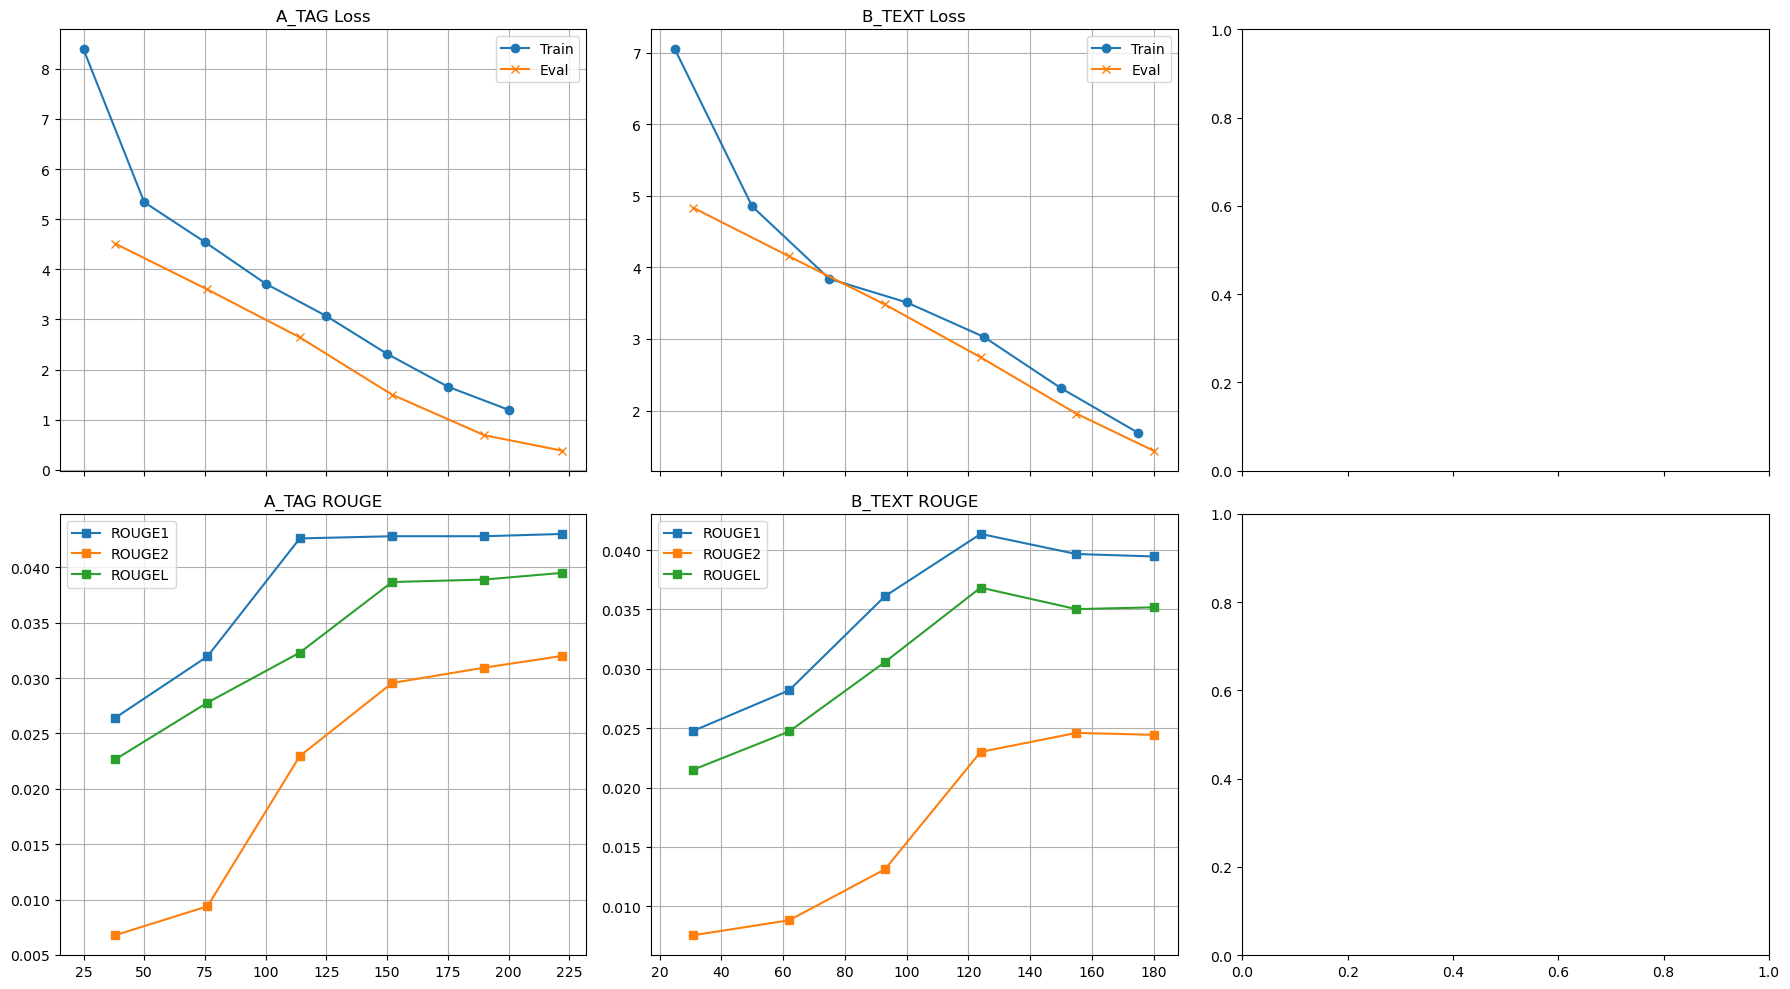

In [10]:
logs = {
    "A_TAG":  pd.DataFrame(trainer_a_tag_bart_large.state.log_history),
    "B_TEXT": pd.DataFrame(trainer_b_text_bart_large.state.log_history),
    #"A_ONLY": pd.DataFrame(trainer_a_only_bart_large.state.log_history),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex='col')

for idx, (title, df) in enumerate(logs.items()):
    ax_loss  = axes[0, idx]
    ax_rouge = axes[1, idx]

    # Plot Train vs Eval Loss
    if "loss" in df.columns:
        ax_loss.plot(df.dropna(subset=["loss"])["step"],
                     df.dropna(subset=["loss"])["loss"],
                     label="Train", marker="o")
    if "eval_loss" in df.columns:
        ax_loss.plot(df.dropna(subset=["eval_loss"])["step"],
                     df.dropna(subset=["eval_loss"])["eval_loss"],
                     label="Eval", marker="x")
    ax_loss.set_title(f"{title} Loss"); ax_loss.legend(); ax_loss.grid(True)

    # Plot ROUGE metrics
    for metric in ["eval_rouge1", "eval_rouge2", "eval_rougeL"]:
        if metric in df.columns:
            sub = df.dropna(subset=[metric])
            label = metric.split("_")[-1].upper()
            ax_rouge.plot(sub["step"], sub[metric], label=label, marker="s")
    ax_rouge.set_title(f"{title} ROUGE"); ax_rouge.legend(); ax_rouge.grid(True)

plt.tight_layout()
plt.show()

In [11]:
torch.cuda.empty_cache()

In [2]:
"""
Chunk text/annotation datasets for LED-base-16384.

This script reads CSVs with columns [doc_id, <input_col>, summary],
splits each <input_col> into fixed-length token chunks (multiple of
ATTENTION_WINDOW), collects basic stats, and writes out:

  • data_processed/A_TAG_LED_chunked.csv
  • data_processed/B_TEXT_LED_chunked.csv
  • data_processed/A_ONLY_LED_chunked.csv
"""

import os
import math
import pandas as pd
from transformers import LEDTokenizerFast

# ——————————————————————————————————————
# Configuration
# ——————————————————————————————————————
DATA_DIR         = "data_processed"
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_NAME_LED   = "allenai/led-base-16384"
ATTENTION_WINDOW = 1024
MAX_TOKENS       = 4096
# ensure MAX_INPUT is a multiple of ATTENTION_WINDOW
MAX_INPUT        = (MAX_TOKENS // ATTENTION_WINDOW) * ATTENTION_WINDOW

SPECIAL_TOKENS = [
    "<highlight>", "</highlight>",
    "<comment>",   "</comment>",
    "<symbol>",    "</symbol>",
]

# dataset definitions: (input_csv, input_column, output_csv)
DATASETS = [
    ("A_TAG.csv",   "text",        f"A_TAG_LED_chunked.csv"),
    ("B_TEXT.csv",  "text",        f"B_TEXT_LED_chunked.csv"),
    ("A_ONLY.csv",  "annotations", f"A_ONLY_LED_chunked.csv"),
]

# ——————————————————————————————————————
# Chunking function
# ——————————————————————————————————————
def chunk_and_save_led(input_csv: str, input_col: str, output_csv: str):
    """
    Read input_csv, tokenize input_col with LED tokenizer,
    split into MAX_INPUT–length chunks, collect stats, and
    save to output_csv.
    """
    # load tokenizer & add special tokens
    tokenizer = LEDTokenizerFast.from_pretrained(MODEL_NAME_LED)
    tokenizer.add_tokens(SPECIAL_TOKENS)

    # read data
    path_in = os.path.join(DATA_DIR, input_csv)
    df      = pd.read_csv(path_in)
    n_docs  = len(df)

    # prepare stats
    stats = {
        "original_docs":        n_docs,
        "total_chunks":         0,
        "max_tokens_original":  0,
        "min_tokens_original":  float("inf"),
        "docs_requiring_chunk": 0,
    }
    total_tokens = 0

    records = []
    for _, row in df.iterrows():
        doc_id    = row["doc_id"]
        input_txt = row[input_col]
        summary   = row["summary"]

        # encode without special tokens
        token_ids = tokenizer.encode(input_txt, add_special_tokens=False)
        length    = len(token_ids)
        total_tokens += length

        # update stats
        stats["max_tokens_original"] = max(stats["max_tokens_original"], length)
        stats["min_tokens_original"] = min(stats["min_tokens_original"], length)

        # compute number of chunks
        num_chunks = math.ceil(length / MAX_INPUT)
        if num_chunks > 1:
            stats["docs_requiring_chunk"] += 1

        # split into chunks
        for idx in range(num_chunks):
            start = idx * MAX_INPUT
            end   = start + MAX_INPUT
            chunk_ids = token_ids[start:end]
            chunk_txt = tokenizer.decode(chunk_ids, skip_special_tokens=False)

            records.append({
                "doc_id":       f"{doc_id}_chunk{idx}" if num_chunks > 1 else doc_id,
                input_col:      chunk_txt,
                "summary":      summary,
                "is_chunk":     num_chunks > 1,
                "chunk_index":  idx if num_chunks > 1 else 0,
                "total_chunks": num_chunks,
            })
        stats["total_chunks"] += num_chunks

    # finalize stats
    stats["avg_tokens_original"] = total_tokens / n_docs

    # save chunks
    output_path = os.path.join(DATA_DIR, output_csv)
    pd.DataFrame(records).to_csv(output_path, index=False)

    # print stats
    print(f"\n=== LED chunking stats for {input_csv} ===")
    print(f" Documents:             {stats['original_docs']}")
    print(f" Total chunks:          {stats['total_chunks']}")
    print(f" Docs needing chunking: {stats['docs_requiring_chunk']} "
          f"({stats['docs_requiring_chunk']/n_docs*100:.1f}%)")
    print(f" Tokens per original doc:")
    print(f"  • Min: {stats['min_tokens_original']}")
    print(f"  • Max: {stats['max_tokens_original']}")
    print(f"  • Avg: {stats['avg_tokens_original']:.1f}")
    print(f" Saved {len(records)} rows to {output_path}")

# ——————————————————————————————————————
# Run chunking for each dataset
# ——————————————————————————————————————
if __name__ == "__main__":
    print(f"Using MAX_INPUT = {MAX_INPUT} tokens (multiple of {ATTENTION_WINDOW})")
    for inp_csv, inp_col, out_csv in DATASETS:
        chunk_and_save_led(inp_csv, inp_col, out_csv)

Using MAX_INPUT = 4096 tokens (multiple of 1024)


Token indices sequence length is longer than the specified maximum sequence length for this model (37832 > 16384). Running this sequence through the model will result in indexing errors



=== LED chunking stats for A_TAG.csv ===
 Documents:             10
 Total chunks:          83
 Docs needing chunking: 10 (100.0%)
 Tokens per original doc:
  • Min: 11318
  • Max: 65858
  • Avg: 31872.5
 Saved 83 rows to data_processed/A_TAG_LED_chunked.csv


Token indices sequence length is longer than the specified maximum sequence length for this model (32494 > 16384). Running this sequence through the model will result in indexing errors



=== LED chunking stats for B_TEXT.csv ===
 Documents:             10
 Total chunks:          71
 Docs needing chunking: 10 (100.0%)
 Tokens per original doc:
  • Min: 9017
  • Max: 61398
  • Avg: 27168.7
 Saved 71 rows to data_processed/B_TEXT_LED_chunked.csv


Token indices sequence length is longer than the specified maximum sequence length for this model (25591 > 16384). Running this sequence through the model will result in indexing errors



=== LED chunking stats for A_ONLY.csv ===
 Documents:             10
 Total chunks:          24
 Docs needing chunking: 8 (80.0%)
 Tokens per original doc:
  • Min: 3897
  • Max: 25591
  • Avg: 8447.6
 Saved 24 rows to data_processed/A_ONLY_LED_chunked.csv


In [3]:
"""
Train LED-base-16384 on three chunked datasets:

  • data_processed/A_TAG_LED_chunked.csv   (column "text")
  • data_processed/B_TEXT_LED_chunked.csv  (column "text")
  • data_processed/A_ONLY_LED_chunked.csv  (column "annotations")

Each run is independent, writes checkpoints to
  • led_a_tag_ckpt/
  • led_b_text_ckpt/
  • led_a_only_ckpt/

Requirements (run once):
  pip install transformers datasets evaluate rouge-score accelerate sentencepiece tensorboard
"""

# ——————————————————————————————————————
# Logging
# ——————————————————————————————————————
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("led_training.log"),
        logging.StreamHandler()
    ],
)

# ——————————————————————————————————————
# Global config
# ——————————————————————————————————————
DATA_DIR          = Path("data_processed")
MODEL_NAME_LED    = "allenai/led-base-16384"
ATTENTION_WINDOW  = 1024
MAX_INPUT_TOKENS  = 4096            # will be truncated to multiple of ATTENTION_WINDOW
MAX_INPUT_TOKENS  = (MAX_INPUT_TOKENS // ATTENTION_WINDOW) * ATTENTION_WINDOW
MAX_TARGET_TOKENS = 1024

BATCH_SIZE   = 1
GRAD_ACCUM   = 8
EPOCHS       = 6
LEARNING_RATE= 3e-5
FP16         = True

SPECIAL_TOKENS = [
    "<highlight>", "</highlight>",
    "<comment>",   "</comment>",
    "<symbol>",    "</symbol>",
]

# Datasets: (csv_name, input_column, checkpoint_dir)
RUNS = [
    ("A_TAG_LED_chunked.csv",   "text",        "led_a_tag_ckpt"),
    ("B_TEXT_LED_chunked.csv",  "text",        "led_b_text_ckpt"),
    ("A_ONLY_LED_chunked.csv",  "annotations", "led_a_only_ckpt"),
]

# ——————————————————————————————————————
# Metric
# ——————————————————————————————————————
rouge = load_metric("rouge")
def compute_metrics(eval_preds, tok):
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tok.pad_token_id)

    decoded_preds  = tok.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tok.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: scores[k] for k in ["rouge1", "rouge2", "rougeL"]}

# ——————————————————————————————————————
# Custom loss logger
# ——————————————————————————————————————
class LossLogger(TrainerCallback):
    def __init__(self):
        self.loss_history = []
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.log_file = f"led_loss_log_{stamp}.json"

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            entry = {
                "step":   int(state.global_step),
                "epoch":  float(state.epoch),
                "loss":   float(logs["loss"]),
            }
            self.loss_history.append(entry)
            with open(self.log_file, "w") as f:
                json.dump(self.loss_history, f, indent=2)

# ——————————————————————————————————————
# Pre-process helper
# ——————————————————————————————————————
def make_preprocess(tok):
    def _fn(batch):
        model_inputs = tok(
            batch["text"],
            max_length=MAX_INPUT_TOKENS,
            truncation=True,
            padding="max_length",
        )
        labels = tok(
            text_target=batch["summary"],
            max_length=MAX_TARGET_TOKENS,
            truncation=True,
            padding="max_length",
        )
        labels["input_ids"] = [
            [(t if t != tok.pad_token_id else -100) for t in lab]
            for lab in labels["input_ids"]
        ]
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs
    return _fn

# ——————————————————————————————————————
# Training routine
# ——————————————————————————————————————
def run_led_experiment(csv_file: str, input_col: str, ckpt_dir: str):
    logging.info(f"\n========== LED run: {csv_file} ==========")

    # Load CSV
    df = pd.read_csv(DATA_DIR / csv_file)
    if input_col != "text":   # unify column name
        df = df.rename(columns={input_col: "text"})
    ds = Dataset.from_pandas(df, preserve_index=False)
    split = ds.train_test_split(test_size=0.1, seed=42)
    train_ds, val_ds = split["train"], split["test"]
    logging.info(f"Docs: train={len(train_ds)}, val={len(val_ds)}")

    # Tokenizer & model
    tok = LEDTokenizerFast.from_pretrained(MODEL_NAME_LED)
    tok.add_tokens(SPECIAL_TOKENS)
    model = LEDForConditionalGeneration.from_pretrained(MODEL_NAME_LED)
    model.resize_token_embeddings(len(tok))

    # Datasets
    preprocess = make_preprocess(tok)
    train_ds = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
    val_ds   = val_ds.map(preprocess,   batched=True, remove_columns=val_ds.column_names)
    collator = DataCollatorForSeq2Seq(tok, model=model)

    # TrainingArgs
    args = Seq2SeqTrainingArguments(
        output_dir               = ckpt_dir,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        num_train_epochs         = EPOCHS,
        learning_rate            = LEARNING_RATE,
        warmup_steps             = 200,
        weight_decay             = 0.01,
        evaluation_strategy      = "epoch",
        save_strategy            = "epoch",
        logging_strategy         = "steps",
        logging_steps            = 10,
        load_best_model_at_end   = True,
        metric_for_best_model    = "rougeL",
        fp16                     = FP16 and torch.cuda.is_available(),
        predict_with_generate    = True,
        generation_max_length    = MAX_TARGET_TOKENS,
        logging_dir              = f"{ckpt_dir}/tb_logs",
        report_to                = ["tensorboard"],
    )

    # Trainer
    trainer = Seq2SeqTrainer(
        model           = model,
        args            = args,
        train_dataset   = train_ds,
        eval_dataset    = val_ds,
        data_collator   = collator,
        compute_metrics = lambda p: compute_metrics(p, tok),
        callbacks       = [LossLogger(), EarlyStoppingCallback(2)],
        tokenizer       = tok,
    )

    # Train
    trainer.train()
    trainer.save_model()
    tok.save_pretrained(ckpt_dir)
    logging.info(f"Saved model + tokenizer to {ckpt_dir}")

    # Final evaluation
    final_metrics = trainer.evaluate()
    with open(Path(ckpt_dir) / "final_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=2)
    logging.info(f"Final metrics: {final_metrics}")

    return trainer

# ——————————————————————————————————————
# Run all three datasets
# ——————————————————————————————————————
trainer_led_a_tag  = run_led_experiment("A_TAG_LED_chunked.csv",   "text",        "led_a_tag_ckpt")
trainer_led_b_text = run_led_experiment("B_TEXT_LED_chunked.csv",  "text",        "led_b_text_ckpt")
trainer_led_a_only = run_led_experiment("A_ONLY_LED_chunked.csv",  "annotations", "led_a_only_ckpt")

2025-05-05 09:22:05,870 - INFO - 
========== LED run: A_TAG_LED_chunked.csv ==========
2025-05-05 09:22:05,978 - INFO - Docs: train=74, val=9
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Map:   0%|          | 0/74 [00:00<?, ? examples/s]

Map:   0%|          | 0/9 [00:00<?, ? examples/s]

/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_36866/315447005.py:175: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,4.931800,4.278015,0.072100,0.017173,0.052313
2,4.549600,3.802340,0.095447,0.011048,0.080628
3,4.076700,3.633619,0.116823,0.010926,0.102557
4,3.805000,3.487264,0.107798,0.012150,0.092467
5,3.567100,3.296808,0.140861,0.028498,0.100281


...

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_36866/315447005.py:175: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,No log,4.458675,0.109256,0.027788,0.060992
2,4.858700,4.149642,0.093976,0.025180,0.055117
3,4.636400,3.907400,0.120919,0.008181,0.089769
4,4.172000,3.710168,0.131809,0.027998,0.112218
5,3.894700,3.461227,0.105161,0.022067,0.089428


2025-05-05 09:37:15,941 - INFO - Using default tokenizer.
2025-05-05 09:39:19,583 - INFO - Using default tokenizer.
2025-05-05 09:41:24,258 - INFO - Using default tokenizer.
2025-05-05 09:43:28,134 - INFO - Using default tokenizer.
2025-05-05 09:45:32,378 - INFO - Using default tokenizer.
2025-05-05 09:47:01,086 - INFO - Using default tokenizer.
There were missing keys in the checkpoint model loaded: ['led.encoder.embed_tokens.weight', 'led.decoder.embed_tokens.weight', 'lm_head.weight'].
2025-05-05 09:47:14,537 - INFO - Saved model + tokenizer to led_b_text_ckpt


2025-05-05 09:48:22,091 - INFO - Using default tokenizer.
2025-05-05 09:48:23,663 - INFO - Final metrics: {'eval_loss': 3.7101683616638184, 'eval_rouge1': 0.13180928780983006, 'eval_rouge2': 0.027997508789687722, 'eval_rougeL': 0.11221825000545942, 'eval_runtime': 69.0987, 'eval_samples_per_second': 0.116, 'eval_steps_per_second': 0.116, 'epoch': 5.253968253968254}


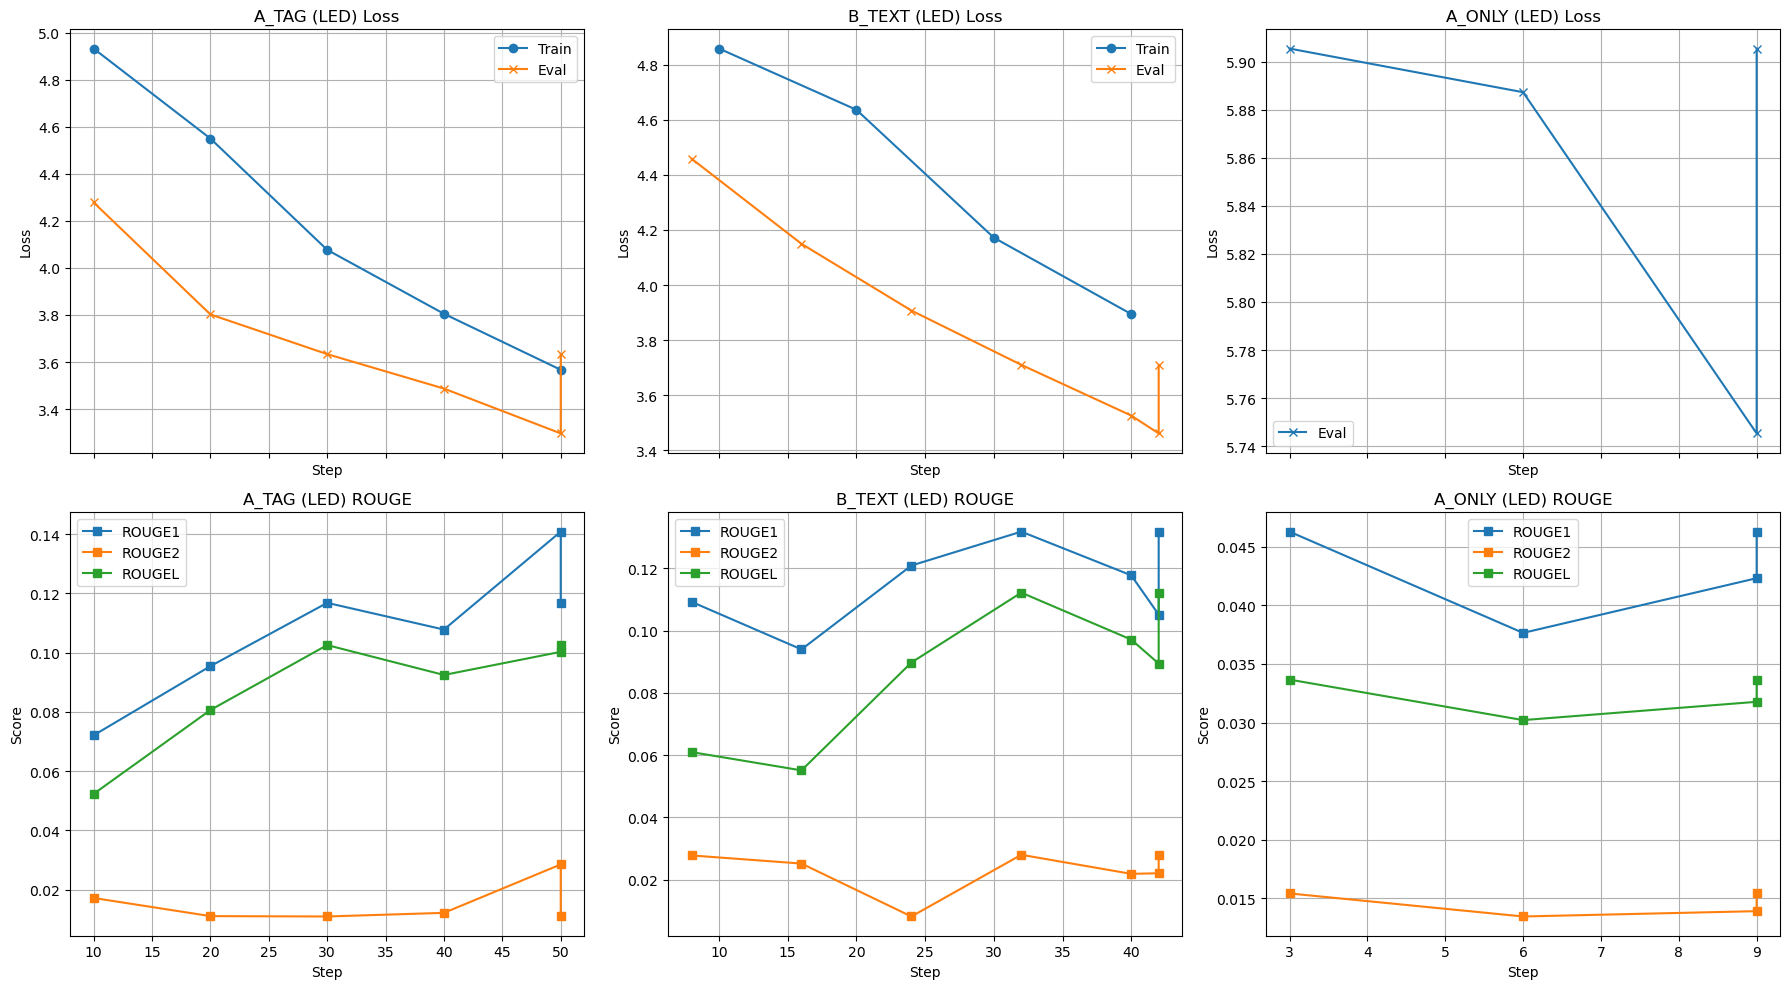

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Collect LED log histories ──
logs_led = {
    "A_TAG":  pd.DataFrame(trainer_led_a_tag.state.log_history),
    "B_TEXT": pd.DataFrame(trainer_led_b_text.state.log_history),
    "A_ONLY": pd.DataFrame(trainer_led_a_only.state.log_history),
}

# ── 2×3 grid: row-0 = losses, row-1 = ROUGE curves ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex="col")

for idx, (title, df) in enumerate(logs_led.items()):
    ax_loss  = axes[0, idx]
    ax_rouge = axes[1, idx]

    # —— Row 0: training vs. evaluation loss —— 
    if "loss" in df.columns:
        ax_loss.plot(
            df.dropna(subset=["loss"])["step"],
            df.dropna(subset=["loss"])["loss"],
            label="Train", marker="o"
        )
    if "eval_loss" in df.columns:
        ax_loss.plot(
            df.dropna(subset=["eval_loss"])["step"],
            df.dropna(subset=["eval_loss"])["eval_loss"],
            label="Eval", marker="x"
        )
    ax_loss.set_title(f"{title} (LED) Loss")
    ax_loss.set_xlabel("Step")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)

    # —— Row 1: ROUGE-1, ROUGE-2, ROUGE-L —— 
    for metric in ["eval_rouge1", "eval_rouge2", "eval_rougeL"]:
        if metric in df.columns:
            sub = df.dropna(subset=[metric])
            label = metric.split("_")[-1].upper()
            ax_rouge.plot(
                sub["step"], sub[metric],
                label=label, marker="s"
            )
    ax_rouge.set_title(f"{title} (LED) ROUGE")
    ax_rouge.set_xlabel("Step")
    ax_rouge.set_ylabel("Score")
    ax_rouge.legend()
    ax_rouge.grid(True)

plt.tight_layout()
plt.show()

In [5]:
trainer_led_a_only = run_led_experiment("A_ONLY_LED_chunked.csv",  "annotations", "led_a_only_ckpt")

2025-05-05 09:53:50,966 - INFO - 
========== LED run: A_ONLY_LED_chunked.csv ==========
2025-05-05 09:53:51,000 - INFO - Docs: train=21, val=3


Map:   0%|          | 0/21 [00:00<?, ? examples/s]

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/shared/home/gom133/.local/lib/python3.11/site-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_36866/315447005.py:175: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,No log,5.905377,0.046278,0.015428,0.033661
2,No log,5.887221,0.037644,0.013463,0.030208
3,No log,5.745331,0.042308,0.013918,0.031768


2025-05-05 09:54:34,052 - INFO - Using default tokenizer.
2025-05-05 09:55:22,277 - INFO - Using default tokenizer.
2025-05-05 09:56:10,583 - INFO - Using default tokenizer.
There were missing keys in the checkpoint model loaded: ['led.encoder.embed_tokens.weight', 'led.decoder.embed_tokens.weight', 'lm_head.weight'].
2025-05-05 09:56:21,975 - INFO - Saved model + tokenizer to led_a_only_ckpt


2025-05-05 09:56:47,676 - INFO - Using default tokenizer.
2025-05-05 09:56:48,033 - INFO - Final metrics: {'eval_loss': 5.90537691116333, 'eval_rouge1': 0.04627808570236605, 'eval_rouge2': 0.015427769985974756, 'eval_rougeL': 0.03366112402407771, 'eval_runtime': 26.0343, 'eval_samples_per_second': 0.115, 'eval_steps_per_second': 0.115, 'epoch': 3.0}


In [3]:
trainer_a_only_bart_large = run_experiment("A_ONLY_BART.csv",  "annotations", "bart_large_a_only_checkpoint")

NameError: name 'run_experiment' is not defined